In [1]:
import numpy as np
import pandas as pd

from tqdm import tqdm
from config import config
from xgboost import XGBClassifier
from matplotlib import pyplot as plt
from scipy.ndimage import uniform_filter
from joblib import Parallel, delayed
from utils import (
    build_metadata, plot_class_distribution, split_metadata,
    print_split_summary, preprocess_img,
    encode_labels, decode_labels, count_by_class, evaluate_split, sample_pixels
)


In [2]:
def local_mean_std(x, size=3):
    mean = uniform_filter(x, size=size)
    mean_sq = uniform_filter(x * x, size=size)
    var = np.maximum(mean_sq - mean * mean, 0.0)
    std = np.sqrt(var)
    return mean, std

def normalized_diff(a, b, eps=1e-6):
    return (a - b) / (a + b + eps)

def extract_features(img):
    b_raw = img.astype(np.float32)

    blue = b_raw[1]
    green = b_raw[2]
    red = b_raw[3]
    nir = b_raw[7]
    swir1 = b_raw[10]
    swir2 = b_raw[11]

    h, w = red.shape

    bands_mean = np.mean(b_raw, axis=0)
    bands_std = np.std(b_raw, axis=0)
    brightness = np.mean(b_raw[[1, 2, 3]], axis=0)
    visible_std = np.std(b_raw[[1, 2, 3]], axis=0)

    ndvi = normalized_diff(nir, red)
    ndwi = normalized_diff(green, nir)
    mndwi = normalized_diff(green, swir1)
    ndbi = normalized_diff(swir1, nir)
    ndmi = normalized_diff(nir, swir1)
    nbr = normalized_diff(nir, swir2)
    gndvi = normalized_diff(nir, green)

    bsi = ((swir1 + red) - (nir + blue)) / ((swir1 + red) + (nir + blue) + 1e-6)
    savi = 1.5 * (nir - red) / (nir + red + 0.5 + 1e-6)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + 1e-6)

    msavi_term = (2 * nir + 1) ** 2 - 8 * (nir - red)
    msavi_term = np.maximum(msavi_term, 0.0)
    msavi = (2 * nir + 1 - np.sqrt(msavi_term)) / 2.0

    awei_sh = blue + 2.5 * green - 1.5 * (nir + swir1) - 0.25 * swir2
    awei_nsh = 4.0 * (green - swir1) - (0.25 * nir + 2.75 * swir2)

    nir_red_ratio = nir / (red + 1e-6)
    nir_green_ratio = nir / (green + 1e-6)
    red_green_ratio = red / (green + 1e-6)
    blue_green_ratio = blue / (green + 1e-6)
    swir_ratio = swir1 / (swir2 + 1e-6)
    swir1_red_ratio = swir1 / (red + 1e-6)
    swir1_nir_ratio = swir1 / (nir + 1e-6)

    red_blue_diff = red - blue
    green_red_diff = green - red
    nir_swir1_diff = nir - swir1

    ndvi_mean_3, ndvi_std_3 = local_mean_std(ndvi, size=3)
    ndvi_mean_5, ndvi_std_5 = local_mean_std(ndvi, size=5)
    mndwi_mean_3, mndwi_std_3 = local_mean_std(mndwi, size=3)
    ndbi_mean_3, ndbi_std_3 = local_mean_std(ndbi, size=3)
    nir_mean_3, nir_std_3 = local_mean_std(nir, size=3)
    swir1_mean_3, swir1_std_3 = local_mean_std(swir1, size=3)

    y_coord, x_coord = np.meshgrid(
        np.linspace(0.0, 1.0, h, dtype=np.float32),
        np.linspace(0.0, 1.0, w, dtype=np.float32),
        indexing="ij"
    )

    features = np.concatenate(
        [
            b_raw,
            ndvi[np.newaxis, ...],
            ndwi[np.newaxis, ...],
            mndwi[np.newaxis, ...],
            ndbi[np.newaxis, ...],
            ndmi[np.newaxis, ...],
            nbr[np.newaxis, ...],
            gndvi[np.newaxis, ...],
            bsi[np.newaxis, ...],
            savi[np.newaxis, ...],
            evi[np.newaxis, ...],
            msavi[np.newaxis, ...],
            awei_sh[np.newaxis, ...],
            awei_nsh[np.newaxis, ...],
            brightness[np.newaxis, ...],
            visible_std[np.newaxis, ...],
            bands_mean[np.newaxis, ...],
            bands_std[np.newaxis, ...],
            nir_red_ratio[np.newaxis, ...],
            nir_green_ratio[np.newaxis, ...],
            red_green_ratio[np.newaxis, ...],
            blue_green_ratio[np.newaxis, ...],
            swir_ratio[np.newaxis, ...],
            swir1_red_ratio[np.newaxis, ...],
            swir1_nir_ratio[np.newaxis, ...],
            red_blue_diff[np.newaxis, ...],
            green_red_diff[np.newaxis, ...],
            nir_swir1_diff[np.newaxis, ...],
            ndvi_mean_3[np.newaxis, ...],
            ndvi_std_3[np.newaxis, ...],
            ndvi_mean_5[np.newaxis, ...],
            ndvi_std_5[np.newaxis, ...],
            mndwi_mean_3[np.newaxis, ...],
            mndwi_std_3[np.newaxis, ...],
            ndbi_mean_3[np.newaxis, ...],
            ndbi_std_3[np.newaxis, ...],
            nir_mean_3[np.newaxis, ...],
            nir_std_3[np.newaxis, ...],
            swir1_mean_3[np.newaxis, ...],
            swir1_std_3[np.newaxis, ...],
            x_coord[np.newaxis, ...],
            y_coord[np.newaxis, ...],
        ],
        axis=0,
    )

    feature_names = [f"B{i + 1}" for i in range(b_raw.shape[0])] + [
        "ndvi",
        "ndwi",
        "mndwi",
        "ndbi",
        "ndmi",
        "nbr",
        "gndvi",
        "bsi",
        "savi",
        "evi",
        "msavi",
        "awei_sh",
        "awei_nsh",
        "brightness",
        "visible_std",
        "bands_mean",
        "bands_std",
        "nir_red_ratio",
        "nir_green_ratio",
        "red_green_ratio",
        "blue_green_ratio",
        "swir_ratio",
        "swir1_red_ratio",
        "swir1_nir_ratio",
        "red_blue_diff",
        "green_red_diff",
        "nir_swir1_diff",
        "ndvi_mean_3",
        "ndvi_std_3",
        "ndvi_mean_5",
        "ndvi_std_5",
        "mndwi_mean_3",
        "mndwi_std_3",
        "ndbi_mean_3",
        "ndbi_std_3",
        "nir_mean_3",
        "nir_std_3",
        "swir1_mean_3",
        "swir1_std_3",
        "x_coord",
        "y_coord",
    ]

    return features, feature_names


def process_pair(img_path, mask_path):
    img, mask, confidence, pixel_valid = preprocess_img(img_path, mask_path)
    features, feature_names = extract_features(img)

    valid = pixel_valid & (mask != 0) & (confidence * 100.0 >= config.MIN_CONFIDENCE)
    X = features[:, valid].T.astype(np.float32)
    y = mask[valid].reshape(-1).astype(np.uint8)
    pixel_weight = confidence[valid].reshape(-1).astype(np.float32)

    return X, y, pixel_weight, feature_names


def build_dataset(split_df, n_jobs=-1):
    records = split_df[['img_path', 'mask_path']].to_dict('records')
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(process_pair)(row['img_path'], row['mask_path'])
        for row in tqdm(records, desc='Building dataset')
    )

    X_parts = []
    y_parts = []
    weight_parts = []
    feature_names = None

    for X, y, pixel_weight, names in results:
        X_parts.append(X)
        y_parts.append(y)
        weight_parts.append(pixel_weight)
        if feature_names is None:
            feature_names = names

    X_all = np.concatenate(X_parts, axis=0)
    y_all = np.concatenate(y_parts, axis=0)
    weight_all = np.concatenate(weight_parts, axis=0)
    return X_all, y_all, weight_all, feature_names

In [3]:
meta = build_metadata(config.DATA_DIR)
train_meta, val_meta, test_meta = split_metadata(meta)

print_split_summary('train', train_meta)
print_split_summary('val', val_meta)
print_split_summary('test', test_meta)

Scanning masks: 100%|██████████| 322/322 [00:00<00:00, 518.28it/s]

[train] images: 289
  Unknown  pixels=   11,466 images=105
  Greenery pixels=12,605,080 images=275
  Sand     pixels=5,130,726 images=242
  Water    pixels=  356,247 images= 45
  Cement   pixels=  836,385 images=229
  strata: {'cement_only': 189, 'base': 55, 'water_and_cement': 40, 'water_only': 5}
[val] images: 16
  Unknown  pixels=      109 images=  7
  Greenery pixels=  442,238 images= 14
  Sand     pixels=  468,364 images= 14
  Water    pixels=   65,602 images=  3
  Cement   pixels=   72,263 images= 13
  strata: {'cement_only': 11, 'base': 3, 'water_and_cement': 2}
[test] images: 17
  Unknown  pixels=      437 images=  5
  Greenery pixels=  674,131 images= 16
  Sand     pixels=  434,040 images= 15
  Water    pixels=    1,752 images=  2
  Cement   pixels=    3,752 images= 13
  strata: {'cement_only': 11, 'base': 4, 'water_and_cement': 2}


In [4]:
print(train_meta.head())

  sample_id               img_path                mask_path  total_pixels  \
0       177  data/imgs/img_177.tif  data/masks/mask_177.tif         65536   
1       151  data/imgs/img_151.tif  data/masks/mask_151.tif         65536   
2        06   data/imgs/img_06.tif   data/masks/mask_06.tif         65536   
3       321  data/imgs/img_321.tif  data/masks/mask_321.tif         65536   
4       142  data/imgs/img_142.tif  data/masks/mask_142.tif         65536   

   has_water  has_cement  has_sand  count_0  count_1  count_2  count_3  \
0          1           1         1        9    63748      672       12   
1          1           1         1        0    18227      735      491   
2          0           0         1        0        0    65536        0   
3          0           1         1      183     3207    62065        0   
4          0           1         1       69    44174    12728        0   

   count_4           stratum  
0     1095  water_and_cement  
1    46083  water_and_cement  

Building dataset: 100%|██████████| 17/17 [00:00<00:00, 23712.39it/s]


Train full: (18843790, 53) {'Greenery': 12610287, 'Sand': 5098715, 'Water': 297011, 'Cement': 837777}
Val      : (1048576, 53) {'Greenery': 442305, 'Sand': 468375, 'Water': 65627, 'Cement': 72269}
Test     : (1114112, 53) {'Greenery': 674424, 'Sand': 434163, 'Water': 1752, 'Cement': 3773}
Train confidence weight range: 0.33000001311302185 1.0
Greenery available=12,610,287 sampled=  400,000
Sand     available=5,098,715 sampled=  400,000
Water    available=  297,011 sampled=  297,011
Cement   available=  837,777 sampled=  550,000
Greenery available=  442,305 sampled=  100,000
Sand     available=  468,375 sampled=  100,000
Water    available=   65,627 sampled=   65,627
Cement   available=   72,269 sampled=   72,269
Greenery available=  674,424 sampled=  100,000
Sand     available=  434,163 sampled=  100,000
Water    available=    1,752 sampled=    1,752
Cement   available=    3,773 sampled=    3,773
Train sampled: (1647011, 53) {'Greenery': 400000, 'Sand': 400000, 'Water': 297011, 'Cement

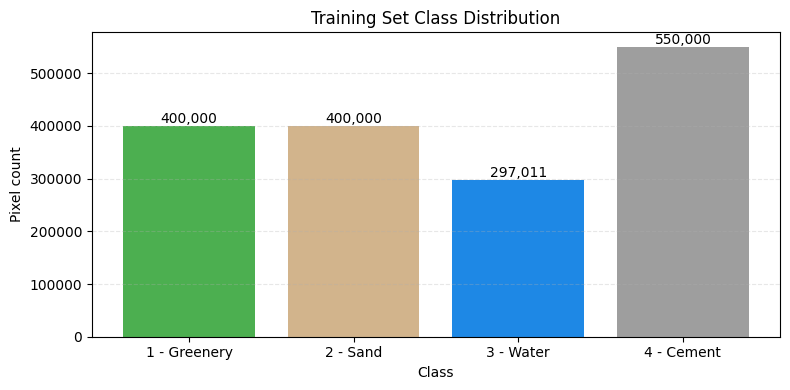

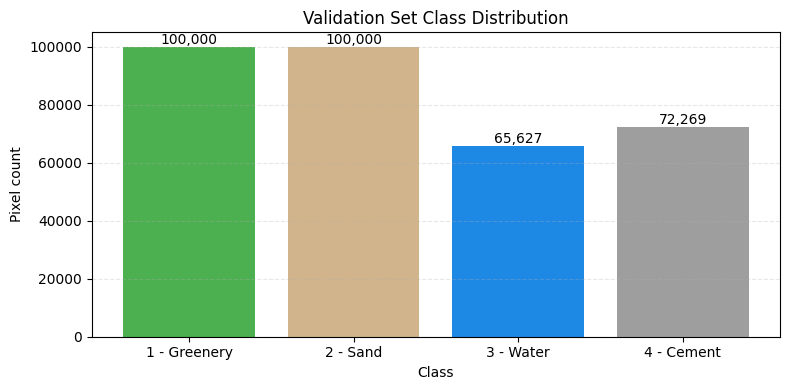

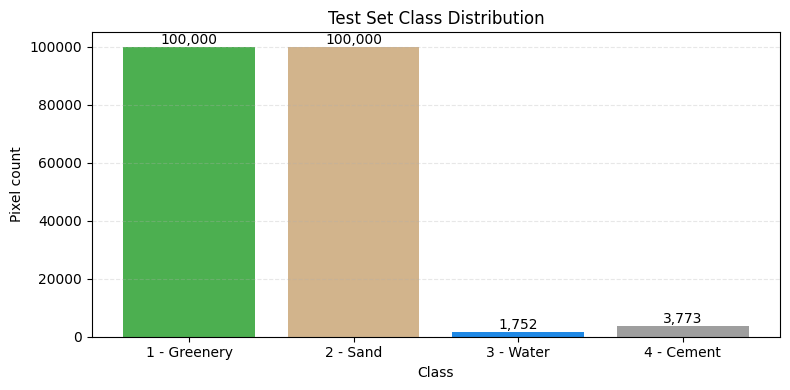

In [5]:
X_train_full, y_train_full, conf_train_full, feature_names = build_dataset(train_meta)
X_val, y_val, _, _ = build_dataset(val_meta)
X_test, y_test, _, _ = build_dataset(test_meta)

print('Train full:', X_train_full.shape, count_by_class(y_train_full))
print('Val      :', X_val.shape, count_by_class(y_val))
print('Test     :', X_test.shape, count_by_class(y_test))
print('Train confidence weight range:', float(conf_train_full.min()), float(conf_train_full.max()))

X_train, y_train, conf_train = sample_pixels(X_train_full, y_train_full, config.TRAIN_CAPS_CLASSIC, conf_train_full)
X_val, y_val, _ = sample_pixels(X_val, y_val, config.VAL_TEST_CAPS, np.ones_like(y_val))
X_test, y_test, _ = sample_pixels(X_test, y_test, config.VAL_TEST_CAPS, np.ones_like(y_test))
print('Train sampled:', X_train.shape, count_by_class(y_train))
print('Val sampled  :', X_val.shape, count_by_class(y_val))
print('Test sampled :', X_test.shape, count_by_class(y_test))
plot_class_distribution(y_train, 'Training Set Class Distribution')
plot_class_distribution(y_val, 'Validation Set Class Distribution')
plot_class_distribution(y_test, 'Test Set Class Distribution')

In [6]:
y_train_enc = encode_labels(y_train)
sample_weight = conf_train.copy()
sample_weight[y_train == 3] *= config.WATER_WEIGHT_MULTIPLIER
sample_weight[y_train == 4] *= config.CEMENT_WEIGHT_MULTIPLIER
print('Weighted classes:', {
    'Water': config.WATER_WEIGHT_MULTIPLIER,
    'Cement': config.CEMENT_WEIGHT_MULTIPLIER,
})

model = XGBClassifier(
    n_estimators=700,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=2.0,
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=config.RANDOM_STATE,
)

model.fit(X_train, y_train_enc, sample_weight=sample_weight)


Weighted classes: {'Water': 3.0, 'Cement': 2.0}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

===== Train =====
              precision    recall  f1-score   support

           1     0.8480    0.8674    0.8576    400000
           2     0.9010    0.8363    0.8674    400000
           3     0.9881    0.9992    0.9936    297011
           4     0.9226    0.9499    0.9360    550000

    accuracy                         0.9111   1647011
   macro avg     0.9149    0.9132    0.9137   1647011
weighted avg     0.9110    0.9111    0.9107   1647011

Confusion Matrix:
 [[346959  28108   2231  22702]
 [ 43599 334500    840  21061]
 [   164      4 296765     78]
 [ 18408   8650    501 522441]]
mIoU: 0.845910697056216
Per-class IoU: {'Greenery': 0.7507156442096107, 'Sand': 0.7658633306011055, 'Water': 0.9872980175192875, 'Cement': 0.8797657958948607}


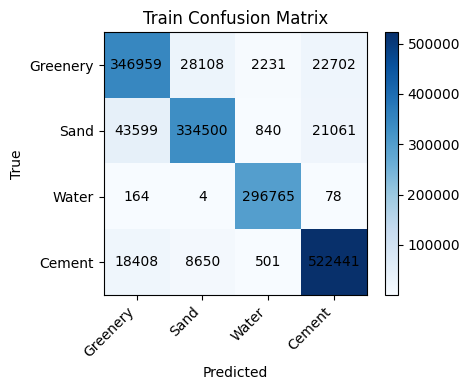

(array([[346959,  28108,   2231,  22702],
        [ 43599, 334500,    840,  21061],
        [   164,      4, 296765,     78],
        [ 18408,   8650,    501, 522441]]),
 0.845910697056216,
 array([0.75071564, 0.76586333, 0.98729802, 0.8797658 ]))

In [7]:
evaluate_split("Train", model, X_train, y_train)

===== Validation =====
              precision    recall  f1-score   support

           1     0.9106    0.8312    0.8691    100000
           2     0.8482    0.8983    0.8725    100000
           3     0.9974    0.9986    0.9980     65627
           4     0.9150    0.9495    0.9319     72269

    accuracy                         0.9089    337896
   macro avg     0.9178    0.9194    0.9179    337896
weighted avg     0.9099    0.9089    0.9086    337896

Confusion Matrix:
 [[83119 13072    88  3721]
 [ 7466 89831    53  2650]
 [   80     6 65536     5]
 [  619  3000    31 68619]]
mIoU: 0.8527124676848234
Per-class IoU: {'Greenery': 0.7684463551056256, 'Sand': 0.7738848015989248, 'Water': 0.9960029787686743, 'Cement': 0.8725157352660691}


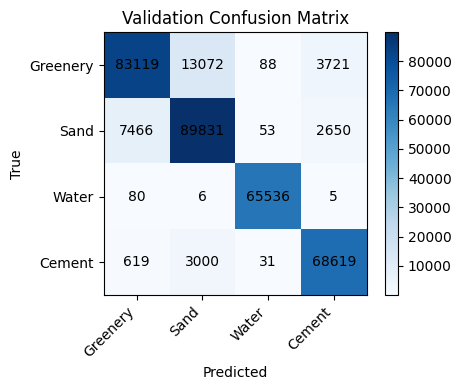

(array([[83119, 13072,    88,  3721],
        [ 7466, 89831,    53,  2650],
        [   80,     6, 65536,     5],
        [  619,  3000,    31, 68619]]),
 0.8527124676848234,
 array([0.76844636, 0.7738848 , 0.99600298, 0.87251574]))

In [8]:
evaluate_split('Validation', model, X_val, y_val)

===== Test =====
              precision    recall  f1-score   support

           1     0.8824    0.8551    0.8685    100000
           2     0.8866    0.8457    0.8656    100000
           3     0.5243    0.9104    0.6654      1752
           4     0.1101    0.2974    0.1607      3773

    accuracy                         0.8407    205525
   macro avg     0.6008    0.7271    0.6401    205525
weighted avg     0.8672    0.8407    0.8524    205525

Confusion Matrix:
 [[85509  8906  1394  4191]
 [10548 84567     9  4876]
 [  150     7  1595     0]
 [  699  1908    44  1122]]
mIoU: 0.5291694700175276
Per-class IoU: {'Greenery': 0.7676059498909307, 'Sand': 0.7630954421995831, 'Water': 0.49859331040950294, 'Cement': 0.08738317757009346}


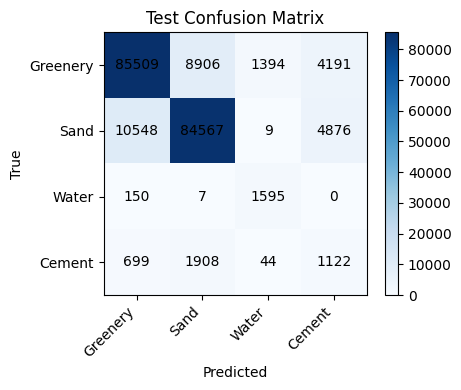

(array([[85509,  8906,  1394,  4191],
        [10548, 84567,     9,  4876],
        [  150,     7,  1595,     0],
        [  699,  1908,    44,  1122]]),
 0.5291694700175276,
 array([0.76760595, 0.76309544, 0.49859331, 0.08738318]))

In [9]:
evaluate_split('Test', model, X_test, y_test)

In [10]:
importance_df = pd.DataFrame(
    {
        'feature': feature_names,
        'importance': model.feature_importances_,
    }
).sort_values('importance', ascending=False)

display(importance_df.head(20))

,feature,importance
24,awei_nsh,0.354426
11,B12,0.125312
23,awei_sh,0.118913
49,swir1_mean_3,0.076014
34,swir1_red_ratio,0.050860
44,mndwi_std_3,0.034760
41,ndvi_mean_5,0.033990
21,evi,0.019158
33,swir_ratio,0.013817
42,ndvi_std_5,0.013763


In [11]:
@np.errstate(divide='ignore', invalid='ignore')
def show_prediction(model, split_df, idx=0):
    row = split_df.iloc[idx]
    img, mask, confidence, pixel_valid = preprocess_img(row['img_path'], row['mask_path'])
    features, _ = extract_features(img)

    valid = pixel_valid & (mask != 0) & (confidence * 100.0 >= config.MIN_CONFIDENCE)
    pred_mask = np.zeros_like(mask, dtype=np.uint8)

    if np.any(valid):
        X = features[:, valid].T.astype(np.float32)
        pred_mask[valid] = decode_labels(model.predict(X))

    rgb = np.transpose(img[[3, 2, 1]], (1, 2, 0))
    rgb = np.clip(rgb * 3.0, 0, 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title('RGB')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='tab10', vmin=0, vmax=4)
    plt.title('Ground Truth')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='tab10', vmin=0, vmax=4)
    plt.title('Prediction')
    plt.axis('off')

    plt.show()

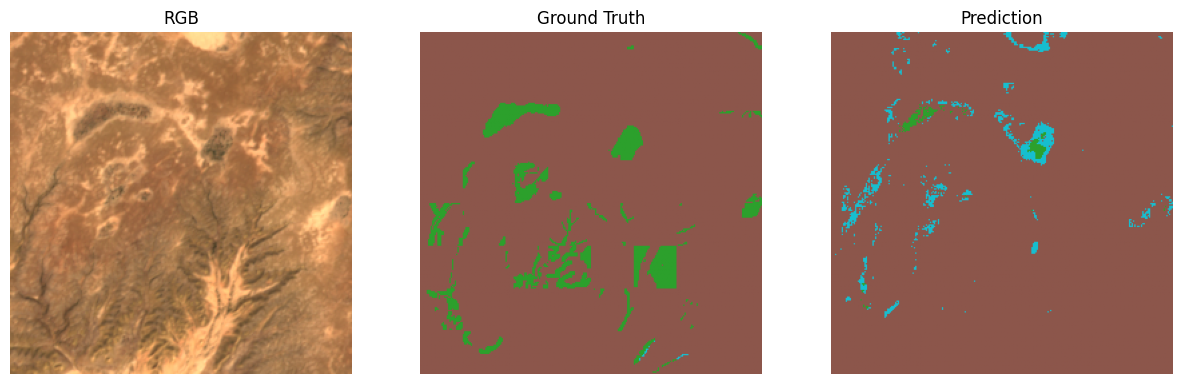

In [30]:
show_prediction(model, test_meta, idx=11)

In [ ]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)